<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/Homocedasticity_Asum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>
© 2026 Germán Almanza ralmanza@uacj.mx


### **De momento esta celda no la utilizamos**

In [ ]:
#       1.
from google.colab import drive

drive.mount('/content/drive')

#       2.
import pandas as pd

path="/content/drive/MyDrive/Colab Notebooks/DataSets/caschool.csv"
CA9899=pd.read_csv(path)

## **Instalamos la paqueteria de Wooldridge**


### **Ejemplo 2.13: Heterocedasticidad en una ecuación del salario**

In [ ]:
!pip install wooldridge

In [ ]:
import statsmodels.formula.api as stf
import wooldridge as woo
import numpy as np

wage1=woo.dataWoo('wage1' )

regresion=stf.ols('np.log(wage)~educ',data=wage1).fit()
regresion.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           np.log(wage)   R-squared:                       0.186
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     119.6
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           3.27e-25
Time:                        03:43:50   Log-Likelihood:                -359.38
No. Observations:                 526   AIC:                             722.8
Df Residuals:                     524   BIC:                             731.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.5838      0.097      5.998      0.000       0.393       0.775
educ           0.0827      0.008     10.935      0.000       0.068       0.098
==============================================================================
Omnibus:                       11.804   Durbin-Watson:                   1.801
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               13.811
Skew:                           0.268   Prob(JB):                      0.00100
Kurtosis:                       3.586   Cond. No.                         60.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# **Supuesto Homocedasticidad (RLS.5)**

Hemos discutido que una propiedad importante de los estimadores de MCO es que son **insesgados**, esto significa que $\widehat \beta_0$ y $\widehat \beta_1$ estan centrados en $\beta_0$ y $\beta_1$, respectivamente. Además, si tenemos control de la **varianza** de estos estimadores; es decir, si la varianza de los estimadores es la misma, esto implica que podemos
elegir los "mejores" estimadores dentro de una amplia clase de estimadores insesgados. Esta última propiedad se llama **eficiencia**. Previo a calcular la varianza de los estimadores, introducimos el **supuesto de homocedasticidad**, esto es porque facilita los cálculos y además agrega la propiedad de **eficiencia** que resulta de gran importancia en MCO.


---
**Homocedasticidad (RLS.5)**

La varianza de los factores inobservables $u$ condicionados a $x$ es constante.

$$var(u|x)=\sigma^2.$$

---

<br>

**Observación 1:** por definición
$$var(u|x)=E(u^2|x)-E(u|x)=E(u^2|x)=\sigma^2.$$

Lo anterior ocurre porque $E(u|x)=0$, observe además que debido a que  $var(u|x)=\sigma^2$ para todo $x$, podemos concluir lo siguiente
$$\sigma^2=E(u^2)=var(u),$$
esto significa que $\sigma^2$ es la varianza **incondicional** de $u$ o **varianza del error**.

<br>

**Observación 2:** el modelo de regresión lineal simple esta definido por $y=\beta_0+\beta_1 x+ u$, de modo que
$E(y|x)=\beta_0+\beta_1 x$, debido a que $\beta_0+\beta_1 x$ es la parte determinista de $y$. Por tanto, la varianza de $y$ depende directamente de la varianza de $u$, en otros términos
$var(y|x)=var(u|x)$.

<br>


# **Pruebas de Homocedasticidad**


La violación del supuesto de homocedasticidad **(RLS.5)**  no causa sesgo en los estimadores, pero <mark>si estimaciones ineficientes y errores estándar inválidos</mark>, tiene las siguientes consecuencias:


*  Los estimadores $\beta_i$ pierden eficiencia,
*  Las pruebas de significancia $t$ y $F$, y  los intervalos de confianza no son confiables.

En python tenemos varias pruebas dentro de la paqueteria `statsmodels.stats.api`

En las pruebas de homocedasticidad **las hipótesis** son:

* $H_0:\;var(u)=\sigma^2$ (homocedasticidad)
* $H_1:$ existe presencia de heterocedasticidad.
* Si $p-value < 0.05$, entonces ${\pmb H_0}$  **se rechaza** y  se concluye que existe heterocedasticidad.

<br>

---

## **Prueba de Breusch-Pagan**

Aplicamos la función
`.het_breuschpagan()` a los resultados de una regresión lineal. Esta función arroja los valores de:

  * `lm`: multiplo de Lagrange LM,
  * `lm_pvalue`: p-value de LM test.
  * `F-stat`: Estadistico $F$ de la hipótesis de la varianza del error no depende de $x$,
  * `F_pvalue`: p-value del estadistico $F$.


**Observación**  la prueba de Breusch-Pagan puede ser inconsistente en los siguientes casos:

* *Muestras pequeñas*, Greene (2002) señala que esta prueba exagera la significancia de los resultados en muestras pequeñas o moderadamente grandes. Para tales casos, sugiere utilizar el estadístico-$F$.

* *Violación de normalidad*, si los residuales no siguen una distribución normal, la prueba de Breuch-Pagan pierde fiabilidad.

*  *Forma funcional no-lineal*, la prueba de Breusch-Pagan busca una relación lineal entre los residuos al cuadrado y las variables independientes. Si la heterocedasticidad tiene una estructura no lineal, esta prueba puede no detectarla.


<br>

---

## **Prueba de White**

Aplicamos la función
`.het_white()` a los resultados de una regresión lineal. Esta función arroja los valores de:

  * `lm`: multiplo de Lagrange LM,
  * `lm_pvalue`: p-value de LM test.
  * `F-stat`: Estadistico $F$ de la hipótesis de la varianza del error no depende de $x$,
  * `F_pvalue`: p-value del estadistico $F$.


Esta prueba no requiere especificar la forma funcional de la heterocedasticidad y detecta formas no lineales, en este sentido es más general que Breusch-Pagan. Sin embargo, puede perder fiabilidad en muestras pequeñas.

<br>

---

### **Otras pruebas**

Se recomienda utilizar otras pruebas como

* **Goldfeld-Quandt:** `.het_goldfeldquandt`, cuando la varianza cambia sistemáticamente con una variable independiente.
* **Levene-Bartlett** `stats.bartlett`,  cuando se comparan grupos especialmente si no hay normalidad.



<br>

---


Nota: Cuando los supuestos 4 (sin autocorrelación) y 5 (homocedasticidad) son ambos verdaderos, los estadísticos dicen que el término de error es independiente e idénticamente distribuido (IID) y se refieren a ellos como errores esféricos.

In [ ]:
import statsmodels.stats.api as sms

#   Definimos nivel de significancia
signif=0.05

# 'regresion': es el nombre de la regresión a evaluar

# 1. Prueba de Breusch-Pagan
BP= sms.het_breuschpagan(regresion.resid, regresion.model.exog)

#   Breusch-Pagan parametros de salida redondeados a 4dig
LMbp=round(BP[0],4)
LMbp_pval=round(BP[1],4)
Fbp_Est=round(BP[2],4)
Fbp_pval=round(BP[3],4)

#    Breusch-Pagan tabla con resultados
import pandas as pd
df = pd.DataFrame({
    'Prueba': ['LM-test', 'F-estadístico'],
    'valor': [LMbp, Fbp_Est],
    'p-value':[LMbp_pval,Fbp_pval]
})
#   Muestra valores
df_BP=df.reset_index(drop=True)
print(df_BP)

#   Resultado de la prueba
print('\nResultado de la prueba de Breusch-Pagan:')
if LMbp_pval < signif:
    print('Dado que p-value < nivel de significancia,\n se rechaza H0: Existe suficiente evidencia de heterocedasticidad.')
else:
    print('Dado que p-value > niv-el de significancia,\n NO se rechaza H0: Existe suficiente evidencia de homocedasticidad.')


          Prueba   valor  p-value
0        LM-test  0.7420    0.389
1  F-estadístico  0.7402    0.390

Resultado de la prueba de Breusch-Pagan:
Dado que p-value > niv-el de significancia,
 NO se rechaza H0: Existe suficiente evidencia de homocedasticidad.


In [ ]:
# 2. Prueba de White

W_test= sms.het_white(regresion.resid, regresion.model.exog)

#   White parametros de salida redondeados a 4dig
LMw=round(W_test[0],4)
LMw_pval=round(W_test[1],4)
Fw_Est=round(W_test[2],4)
Fw_pval=round(W_test[3],4)

#    White tabla con resultados
import pandas as pd
df_w = pd.DataFrame({
    'Prueba': ['LM-test', 'F-estadístico'],
    'valor': [LMw, Fw_Est],
    'p-value':[LMw_pval,Fw_pval]
})
#   Muestra valores
df_w=df_w.reset_index(drop=True)
print(df_w)

#   Resultado de la prueba
print('\nResultado de la prueba de White:')
if LMw_pval < signif:
    print('Dado que p-value < nivel de significancia,\n se rechaza H0: Existe suficiente evidencia de heterocedasticidad.')
else:
    print('Dado que p-value > nivel de significancia,\n NO se rechaza H0: Existe suficiente evidencia de homocedasticidad.')


          Prueba   valor  p-value
0        LM-test  1.1468   0.5636
1  F-estadístico  0.5714   0.5651

Resultado de la prueba de White:
Dado que p-value > nivel de significancia,
 NO se rechaza H0: Existe suficiente evidencia de homocedasticidad.


## **Prueba gráfica: fittedvalues-resid**

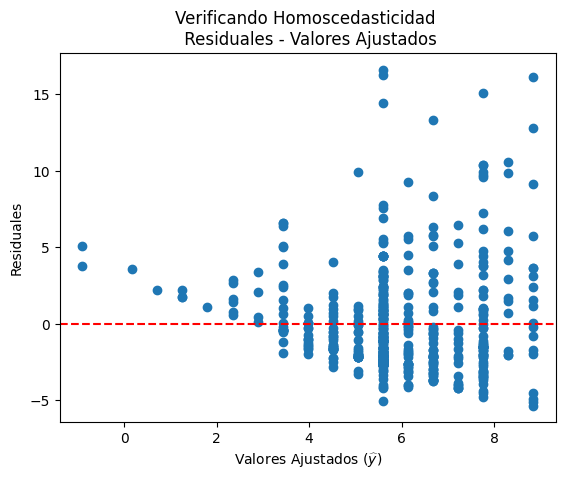

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuos = regresion.resid
ajustados = regresion.fittedvalues


#plt.figure(figsize=(8, 4))
plt.scatter(ajustados,residuos)
#  linea horizontal y=0
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel(r'Valores Ajustados ($\widehat{y}$)')
plt.ylabel('Residuales')
plt.title('Verificando Homoscedasticidad \n Residuales - Valores Ajustados')
plt.show()

## **Economistas Méxicanos Chidas**


Cuando te pregunten si sabes de un economista mexicano reconocido internacionalmente, hay muchos... el primero que me viene a mente es el actual **Gerente General del Banco de Pagos Internacionales** y **Ex-Gobernador de Banxico** (cuando en MX había corrupción), me refiero a **Agustín Carstens**




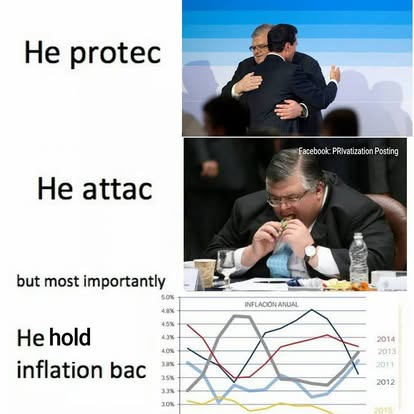


Pero no es el único, en la prueba de normalidad de los residuos Python hace mencion de otro mexicano, **Carlos M. Jarque Uribe**

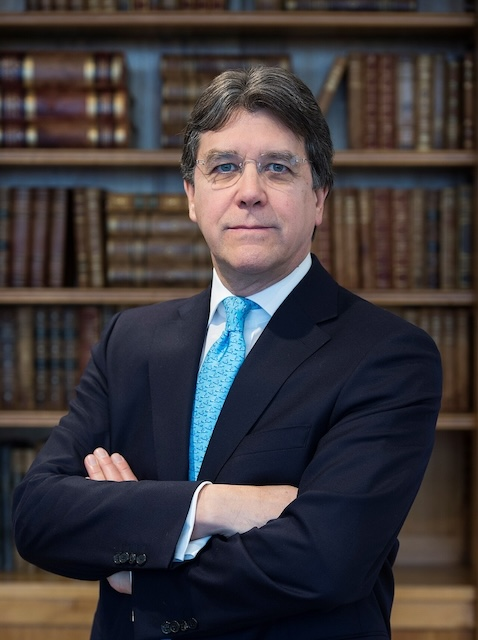


# **Normalidad de residuos (RLM.6)**


La inferencia estadística de los estimadores $\widehat\beta_i$ de MCO depende no solo de las medidas de tendencia central (**RLS.4**) y la varianza (**RLS.5**), es necesario conocer toda la distribución muestral de los estimadores.
Si la distribución muestal esta  condicionada a los valores de las variables independientes $x_{ij}$, entonces la distribución muestral de los $\widehat\beta_i$ depende de la distribución subyacente de los errores. Por lo tanto, para simplificar el cálculo vamos a agregar el supuesto que el error esta distribuido normalmente.


---
**Normalidad (RLM.6)**

El error poblacional $u$ es independiente de las variables explicativas $x_i$ para $i=1,2,\dots,k$ y esta distribuido normalmente, con $\mu=0$ y $var(u)=\sigma^2$


$$u\;\sim\;\text{Normal}(\mu=0,var(u)=\sigma^2).$$

---

<br>




## **Pruebas de Normalidad**

* Shapiro-Wilk Test

* Anderson-Darling Test

* Gráficos Q-Q

---

<br>

### **Jarque-Bera test**



La prueba de normalidad Jarque-Bera es una prueba asintótica; es decir, se recomienda para una muestra grande (n>2000)


**Las hipótesis** de prueba son:

* $H_0:\;u\;\sim\;\text{Normal}(0,\sigma^2)$ Existe distribución Normal

* $H_1:$ NO existe distribución Normal
* Si $p-value < 0.05$, entonces ${\pmb H_0}$  **se rechaza** y  se concluye que NO existe Normalidad.







In [ ]:
import statsmodels.stats.stattools as stool
import numpy as np

residuos = regresion.resid
#     1. Prueba de Jarque-Bera para normalidad de residuales
JB_norm=stool.jarque_bera(residuos)
#     2. Resultados de salida
JB_stat=JB_norm[0]
JB_pval=JB_norm[1]
JB_skew=JB_norm[2]
JB_kurt=JB_norm[3]

print(f"Asimetría: {JB_skew:.4f}")
print(f"Kurtosis: {JB_kurt:.4f}")
print(f"Estadístico Jarque-Bera: {JB_stat:.4f}")
print(f"p-value: {JB_pval:.4f}")

# Interpretación
if JB_pval < 0.05:
    print("Se rechaza H0: NO existe evidencia suficiente de distribución normal")
else:
    print("NO se rechaza H0:  existe evidencia suficiente de distribución normal")


Asimetría: 1.8607
Kurtosis: 7.7970
Estadístico Jarque-Bera: 807.8433
p-value: 0.0000
Se rechaza H0: NO existe evidencia suficiente de distribución normal


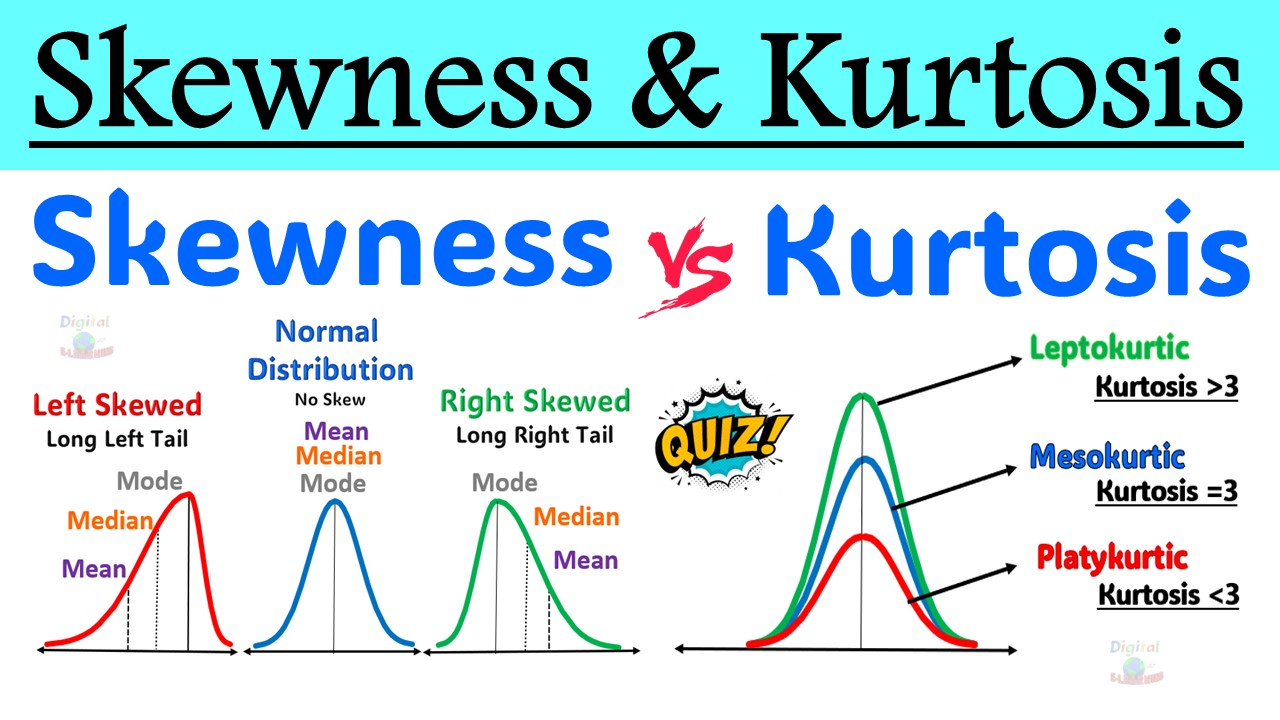

Shapiro-Wilk Test Statistic: 0.9801
Shapiro-Wilk p-value: 0.0000
Se rechaza H0:  existe evidencia suficiente de distribución normal


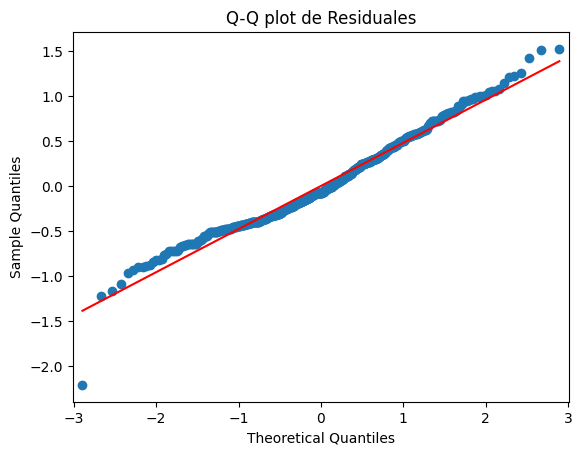

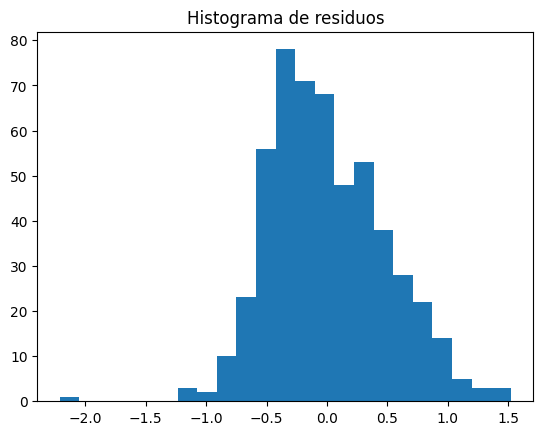

In [ ]:
from scipy.stats import shapiro
import statsmodels.api as sm

# 1. Obtenemos los residuales
residuos=regresion.resid
# 2. Shapiro-Wilk test en los residuales
shapiro_test_statistic, shapiro_p_value = shapiro(residuos)

print(f"Shapiro-Wilk Test Statistic: {shapiro_test_statistic:.4f}")
print(f"Shapiro-Wilk p-value: {shapiro_p_value:.4f}")

# 3. Interpretacion
alpha = 0.05
if shapiro_p_value > alpha:
    print("NO se rechaza H0: no existe evidencia suficiente de distribución normal")
else:
    print("Se rechaza H0:  existe evidencia suficiente de distribución normal")

#  4. Visualiare los residuales usando Q-Q plot
sm.qqplot(residuos, line='s')
plt.title('Q-Q plot de Residuales')

plt.show()

# 5. Histograma
plt.hist(residuos, bins='auto')

plt.title("Histograma de residuos")

plt.show()

